In [28]:
import os
import numpy as np
import seaborn as sn
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
import timm
from sklearn.model_selection import KFold

In [11]:
meningioma_num = len(os.listdir('src_data/1'))
glioma_num = len(os.listdir('src_data/2'))
pituitary_num = len(os.listdir('src_data/3'))
print(f'Number of meningioma images is {meningioma_num} , number of glioma images is {glioma_num} and number of pituitary images is {pituitary_num}')

Number of meningioma images is 708 , number of glioma images is 1426 and number of pituitary images is 930


In [12]:
# test_proportion = 0.25
# val_proportion = 0.2
# test_meningioma_size = int(np.ceil(meningioma_num * test_proportion))
# val_meningioma_size = int(0.2 * int(meningioma_num - test_meningioma_size))
# train_meningioma_size = int(meningioma_num - test_meningioma_size - val_meningioma_size)
# test_glioma_size = int(np.ceil(glioma_num * test_proportion))
# val_glioma_size = int(0.2 * int(glioma_num - test_glioma_size))
# train_glioma_size = int(glioma_num - test_glioma_size - val_glioma_size)
# test_pituitary_size = int(np.ceil(pituitary_num * test_proportion))
# val_pituitary_size = int(0.2 * int(pituitary_num - test_pituitary_size))
# train_pituitary_size = int(pituitary_num - test_pituitary_size - val_pituitary_size)
# print(f'Number of meningioma samples in train set = {train_meningioma_size}')
# print(f'Number of meningioma samples in validation set = {val_meningioma_size}')
# print(f'Number of meningioma samples in test set = {test_meningioma_size}')
# print(f'Number of glioma samples in train set = {train_glioma_size}')
# print(f'Number of glioma samples in validation set = {val_glioma_size}')
# print(f'Number of glioma samples in test set = {test_glioma_size}')
# print(f'Number of pituitary samples in train set = {train_pituitary_size}')
# print(f'Number of pituitary samples in validation set = {val_pituitary_size}')
# print(f'Number of pituitary samples in test set = {test_pituitary_size}')

In [13]:
test_proportion = 0.25
test_meningioma_size = int(np.ceil(meningioma_num * test_proportion))
train_meningioma_size = int(meningioma_num - test_meningioma_size)
test_glioma_size = int(np.ceil(glioma_num * test_proportion))
train_glioma_size = int(glioma_num - test_glioma_size)
test_pituitary_size = int(np.ceil(pituitary_num * test_proportion))
train_pituitary_size = int(pituitary_num - test_pituitary_size)
print(f'Number of meningioma samples in train set = {train_meningioma_size}')
print(f'Number of meningioma samples in test set = {test_meningioma_size}')
print(f'Number of glioma samples in train set = {train_glioma_size}')
print(f'Number of glioma samples in test set = {test_glioma_size}')
print(f'Number of pituitary samples in train set = {train_pituitary_size}')
print(f'Number of pituitary samples in test set = {test_pituitary_size}')

Number of meningioma samples in train set = 531
Number of meningioma samples in test set = 177
Number of glioma samples in train set = 1069
Number of glioma samples in test set = 357
Number of pituitary samples in train set = 697
Number of pituitary samples in test set = 233


In [14]:
#make dataset directory then we arrange dataset manually using cut and paste
os.makedirs('data/train/meningioma', exist_ok=True)
os.makedirs('data/test/meningioma', exist_ok=True)
os.makedirs('data/train/glioma', exist_ok=True)
os.makedirs('data/test/glioma', exist_ok=True)
os.makedirs('data/train/pituitary', exist_ok=True)
os.makedirs('data/test/pituitary', exist_ok=True)

In [15]:
# Define the transformation pipelines
torch.manual_seed(40)
train_transform_0 = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Resize((256, 256), antialias=True),
    transforms.Normalize(mean=[0, 0, 0], std=[255, 255, 255]),  # Normalize the image
])

# Load the dataset using ImageFolder
train_dataset_0 = ImageFolder('data/train', transform=train_transform_0)

# # Create a data loader
# train_loader = torch.utils.data.DataLoader(
#     train_dataset_0,
#     batch_size=50,
#     shuffle=True,
#     num_workers=5,
# )
# len(train_loader)

In [16]:
# Define the transformation pipelines
torch.manual_seed(40)
train_transform_0 = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Resize((256, 256), antialias=True),
    transforms.Normalize(mean=[0, 0, 0], std=[255, 255, 255]),  # Normalize the image
])

# Load the dataset using ImageFolder
train_dataset_50 = ImageFolder('data_50_percent/train', transform=train_transform_0)

In [17]:
# Define the transformation pipelines
torch.manual_seed(40)
train_transform_0 = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Resize((256, 256), antialias=True),
    transforms.Normalize(mean=[0, 0, 0], std=[255, 255, 255]),  # Normalize the image
])

# Load the dataset using ImageFolder
train_dataset_60 = ImageFolder('data_60_percent/train', transform=train_transform_0)

In [18]:
# Define the transformation pipelines
torch.manual_seed(40)
train_transform_0 = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Resize((256, 256), antialias=True),
    transforms.Normalize(mean=[0, 0, 0], std=[255, 255, 255]),  # Normalize the image
])

# Load the dataset using ImageFolder
train_dataset_75 = ImageFolder('data_75_percent/train', transform=train_transform_0)

In [19]:
torch.manual_seed(40)
test_transform = transforms.Compose([
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Resize((256, 256), antialias=True),
    transforms.Normalize(mean=[0, 0, 0], std=[255, 255, 255]),  # Normalize the image
])
test_dataset = ImageFolder('data/test', transform=test_transform)

# Create a data loader
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=50,
    shuffle=True,
    num_workers=5,
)

In [21]:
train_dataset_0.class_to_idx

{'glioma': 0, 'meningioma': 1, 'pituitary': 2}

In [22]:
device = torch.device('cuda:0')
# 'glioma': 0, 'meningioma': 1, 'pituitary': 2
glioma_weight = torch.FloatTensor(
    [1-(train_glioma_size/(train_glioma_size+train_meningioma_size+train_pituitary_size))]
)

meningioma_weight = torch.FloatTensor(
    [1-(train_meningioma_size/(train_glioma_size+train_meningioma_size+train_pituitary_size))]
)

pituitary_weight = torch.FloatTensor(
    [1-(train_pituitary_size/(train_glioma_size+train_meningioma_size+train_pituitary_size))]
)

weights = torch.tensor([glioma_weight, meningioma_weight, pituitary_weight]).to(device)

# Training

In [524]:
torch.cuda.empty_cache()

In [446]:
base_model = timm.create_model('inception_resnet_v2', pretrained=True)

In [447]:
# Save model to local storage

# torch.save(base_model.state_dict(), 'models/base_model.pth')

In [448]:
# load model from local storage

# base_model = models.efficientnet_b2()
# base_model.load_state_dict(torch.load('models/base_model.pth'))

In [449]:
base_model.classif

Linear(in_features=1536, out_features=1000, bias=True)

In [450]:
model = base_model
torch.manual_seed(40)
# freeze all parameters
for name, para in model.named_parameters():
    para.requires_grad = False
    
model.classif = nn.Sequential(
    nn.Linear(in_features=1536, out_features=2048),
    nn.LeakyReLU(0.2),
    nn.Dropout(p=0.4),
    nn.Linear(in_features=2048, out_features=2048),
    nn.LeakyReLU(0.2),
    nn.Dropout(p=0.4),
    nn.Linear(in_features=2048, out_features=1024),
    nn.LeakyReLU(0.2),
    nn.Dropout(p=0.4),
    nn.Linear(in_features=1024, out_features=3),
    nn.Sigmoid(),
)

# turn requires_grad to True for classifier section
for name, para in model.classif.named_parameters():
    para.requires_grad = True
    print("-"*20)
    print(f"name: {name} requires_grad = True")

--------------------
name: 0.weight requires_grad = True
--------------------
name: 0.bias requires_grad = True
--------------------
name: 3.weight requires_grad = True
--------------------
name: 3.bias requires_grad = True
--------------------
name: 6.weight requires_grad = True
--------------------
name: 6.bias requires_grad = True
--------------------
name: 9.weight requires_grad = True
--------------------
name: 9.bias requires_grad = True


In [451]:
# Count the number of parameters in a specific layer
layer_name = 'classif'
num_params = sum(p.numel() for name, p in model.named_parameters() if layer_name in name)
print(f"Number of parameters in {layer_name} layer: {num_params}")

# Count the total number of parameters in the entire model
num_total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters in the model: {num_total_params}")


Number of parameters in classif layer: 9445379
Total number of parameters in the model: 63751843


In [452]:
model.classif

Sequential(
  (0): Linear(in_features=1536, out_features=2048, bias=True)
  (1): LeakyReLU(negative_slope=0.2)
  (2): Dropout(p=0.4, inplace=False)
  (3): Linear(in_features=2048, out_features=2048, bias=True)
  (4): LeakyReLU(negative_slope=0.2)
  (5): Dropout(p=0.4, inplace=False)
  (6): Linear(in_features=2048, out_features=1024, bias=True)
  (7): LeakyReLU(negative_slope=0.2)
  (8): Dropout(p=0.4, inplace=False)
  (9): Linear(in_features=1024, out_features=3, bias=True)
  (10): Sigmoid()
)

In [31]:
def train(model, trainloader, optimizer, device):
    model.train()
    actual_labels = []
    predicted_labels = []
    running_loss = 0.0
    for i, data in enumerate(trainloader):
        inputs, labels = data[0].to(device), data[1].to(device)
        criterion = nn.CrossEntropyLoss(weight=weights)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())
    accuracy = (np.array(predicted_labels) == np.array(actual_labels)).sum() / len(predicted_labels)
    return running_loss / len(trainloader), accuracy

In [34]:
def validate(model, val_loader, device):
    # model.eval()
    actual_labels = []
    predicted_labels = []
    total_loss = 0.0
    num_batches = 0
    with torch.inference_mode():
        for i, data in enumerate(val_loader):
            inputs, labels = data[0].to(device), data[1].to(device)
            # class_weights = torch.empty((len(data[1]), 1), dtype=torch.float32)
            # for i, j in enumerate(labels):
            #     class_weights[i][0] = dict_weights[int(j.item())]
            criterion = nn.CrossEntropyLoss(weight=weights)            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            num_batches += 1
            predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
            predicted_labels.extend(predictions)
            actual_labels.extend(labels.cpu().numpy())
    accuracy = (np.array(predicted_labels) == np.array(actual_labels)).sum() / len(predicted_labels)
    return total_loss / num_batches, accuracy

In [455]:
lr = 0.0001

# Initialize the model and the optimizer
model = model.to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

train_loss = np.zeros((0))
train_acc = np.zeros((0))
val_loss = np.zeros((0))
val_acc = np.zeros((0))
total_epoch_counter = 0
# val_loss_counter = 0
loss_prev = 99999999 #initialized as inf 

In [576]:
model_0 = timm.create_model('inception_resnet_v2', pretrained=True)
model_1 = timm.create_model('inception_resnet_v2', pretrained=True)
model_2 = timm.create_model('inception_resnet_v2', pretrained=True)
model_3 = timm.create_model('inception_resnet_v2', pretrained=True)
model_4 = timm.create_model('inception_resnet_v2', pretrained=True)
model = {0 : model_0, 1 : model_1, 2 : model_2, 3 : model_3, 4 : model_4}

In [577]:
torch.cuda.empty_cache()
kfold = KFold(n_splits=5, shuffle=True, random_state=40)
train_loss = np.zeros((5, 5))
train_acc = np.zeros((5, 5))
val_loss = np.zeros((5, 5))
val_acc = np.zeros((5, 5))
for fold, (train_ids, val_ids) in enumerate(kfold.split(train_dataset_0)):
    
    # Print
    print(f'FOLD {fold}')
    print('--------------------------------')
    train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
    val_subsampler = torch.utils.data.SubsetRandomSampler(val_ids)
    
    train_loader = torch.utils.data.DataLoader(
    train_dataset_0,
    batch_size=50,
    sampler=train_subsampler,
    num_workers=5,
    )
    
    val_loader = torch.utils.data.DataLoader(
    train_dataset_0,
    batch_size=50,
    sampler=val_subsampler,
    num_workers=5,
    )

    torch.manual_seed(40)
    # freeze all parameters
    for name, para in model[fold].named_parameters():
        para.requires_grad = False

    model[fold].classif = nn.Sequential(
        nn.Linear(in_features=1536, out_features=2048),
        nn.LeakyReLU(0.2),
        nn.Dropout(p=0.4),
        nn.Linear(in_features=2048, out_features=2048),
        nn.LeakyReLU(0.2),
        nn.Dropout(p=0.4),
        nn.Linear(in_features=2048, out_features=1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(p=0.4),
        nn.Linear(in_features=1024, out_features=3),
        nn.Sigmoid(),
    )

    # turn requires_grad to True for classifier section
    for name, para in model[fold].classif.named_parameters():
        para.requires_grad = True

    lr = 0.0001

    # Initialize the model[fold] and the optimizer
    model[fold] = model[fold].to(device)
    optimizer = optim.Adam(model[fold].parameters(), lr=lr)


    total_epoch_counter = 0
    # val_loss_counter = 0
    loss_prev = 99999999 #initialized as inf 

    num_epochs = 5
    torch.manual_seed(40)

    for epoch in range(num_epochs):
        # train for one epoch
        loss, train_acc[fold, total_epoch_counter] = train(model[fold], train_loader, optimizer, device)
        train_loss[fold, total_epoch_counter] = loss
        print('Train.', end=' ')
        # calculate validation loss for this epoch
        val_loss[fold, total_epoch_counter], val_acc[fold, total_epoch_counter] = validate(model[fold], val_loader, device)
        # print the results for this epoch
        print('Epoch [{}/{}], Train loss: {:.4f}, lr: {:.7f}, Validation loss: {:.4f}'
               .format(epoch+1, num_epochs, loss, lr,
                        val_loss[fold, total_epoch_counter]
                      )
             )

        if (loss_prev < loss):
            lr = lr * 0.4
            optimizer = optim.Adam(model[fold].parameters(), lr=lr)        
        loss_prev = loss

        total_epoch_counter += 1

FOLD 0
--------------------------------
Train. Epoch [1/5], Train loss: 1.0391, lr: 0.0001000, Validation loss: 0.8937
Train. Epoch [2/5], Train loss: 0.8070, lr: 0.0001000, Validation loss: 0.7634
Train. Epoch [3/5], Train loss: 0.7233, lr: 0.0001000, Validation loss: 0.7121
Train. Epoch [4/5], Train loss: 0.7038, lr: 0.0001000, Validation loss: 0.7157
Train. Epoch [5/5], Train loss: 0.6885, lr: 0.0001000, Validation loss: 0.7054
FOLD 1
--------------------------------
Train. Epoch [1/5], Train loss: 1.0377, lr: 0.0001000, Validation loss: 0.8831
Train. Epoch [2/5], Train loss: 0.8059, lr: 0.0001000, Validation loss: 0.8615
Train. Epoch [3/5], Train loss: 0.7366, lr: 0.0001000, Validation loss: 0.7329
Train. Epoch [4/5], Train loss: 0.7084, lr: 0.0001000, Validation loss: 0.7053
Train. Epoch [5/5], Train loss: 0.6924, lr: 0.0001000, Validation loss: 0.7007
FOLD 2
--------------------------------
Train. Epoch [1/5], Train loss: 1.0336, lr: 0.0001000, Validation loss: 0.8889
Train. Epoc

In [456]:
num_epochs = 30
torch.manual_seed(40)
train_loss = np.concatenate((train_loss, np.zeros((num_epochs))), )
train_acc = np.concatenate((train_acc, np.zeros((num_epochs))), )
val_loss = np.concatenate((val_loss, np.zeros((num_epochs))), )
val_acc = np.concatenate((val_acc, np.zeros((num_epochs))), )

for epoch in range(num_epochs):
    # train for one epoch
    loss, train_acc[total_epoch_counter] = train(model, train_loader, optimizer, device)
    train_loss[total_epoch_counter] = loss
    print('Train.', end=' ')
    # calculate validation loss for this epoch
    val_loss[total_epoch_counter], val_acc[total_epoch_counter] = validate(model, val_loader, device)
    # print the results for this epoch
    print('Epoch [{}/{}], Train loss: {:.4f}, lr: {:.7f}, Validation loss: {:.4f}'
           .format(epoch+1, num_epochs, loss, lr,
                    val_loss[total_epoch_counter]
                  )
         )
    
    if (loss_prev < loss):
        lr = lr * 0.4
        optimizer = optim.Adam(model.parameters(), lr=lr)        
    loss_prev = loss

    total_epoch_counter += 1
    # val_loss_counter += 1

Train. Epoch [1/30], Train loss: 1.0220, lr: 0.0001000, Validation loss: 0.9791
Train. Epoch [2/30], Train loss: 0.8034, lr: 0.0001000, Validation loss: 0.7786
Train. Epoch [3/30], Train loss: 0.7080, lr: 0.0001000, Validation loss: 0.7404
Train. Epoch [4/30], Train loss: 0.6840, lr: 0.0001000, Validation loss: 0.7170
Train. Epoch [5/30], Train loss: 0.6581, lr: 0.0001000, Validation loss: 0.7117
Train. Epoch [6/30], Train loss: 0.6515, lr: 0.0001000, Validation loss: 0.7335
Train. Epoch [7/30], Train loss: 0.6427, lr: 0.0001000, Validation loss: 0.7590
Train. Epoch [8/30], Train loss: 0.6778, lr: 0.0001000, Validation loss: 0.7206
Train. Epoch [9/30], Train loss: 0.6329, lr: 0.0000400, Validation loss: 0.6935
Train. Epoch [10/30], Train loss: 0.6222, lr: 0.0000400, Validation loss: 0.7070
Train. Epoch [11/30], Train loss: 0.6242, lr: 0.0000400, Validation loss: 0.7178
Train. Epoch [12/30], Train loss: 0.6141, lr: 0.0000160, Validation loss: 0.7358
Train. Epoch [13/30], Train loss: 0.6

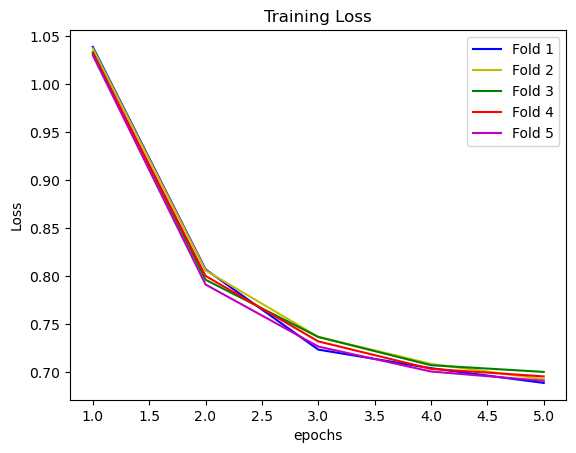

In [587]:
x = np.arange(1,len(train_loss)+1)
plt.plot(x, train_loss[0], 'b', label='Fold 1')
plt.plot(x, train_loss[1], 'y', label='Fold 2')
plt.plot(x, train_loss[2], 'g', label='Fold 3')
plt.plot(x, train_loss[3], 'r', label='Fold 4')
plt.plot(x, train_loss[4], 'm', label='Fold 5')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

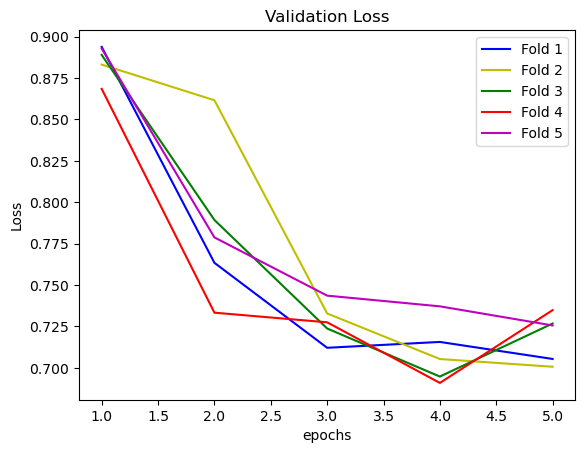

In [588]:
x = np.arange(1,len(val_loss)+1)
plt.plot(x, val_loss[0], 'b', label='Fold 1')
plt.plot(x, val_loss[1], 'y', label='Fold 2')
plt.plot(x, val_loss[2], 'g', label='Fold 3')
plt.plot(x, val_loss[3], 'r', label='Fold 4')
plt.plot(x, val_loss[4], 'm', label='Fold 5')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()
plt.show()

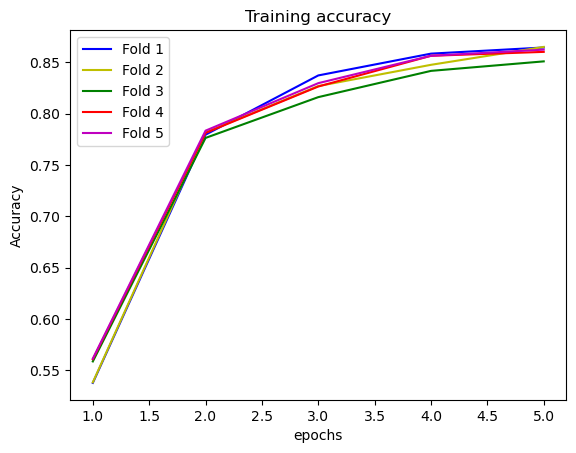

In [593]:
x = np.arange(1,len(train_acc)+1)
plt.plot(x, train_acc[0], 'b', label='Fold 1')
plt.plot(x, train_acc[1], 'y', label='Fold 2')
plt.plot(x, train_acc[2], 'g', label='Fold 3')
plt.plot(x, train_acc[3], 'r', label='Fold 4')
plt.plot(x, train_acc[4], 'm', label='Fold 5')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.title('Training accuracy')
plt.legend()
plt.show()

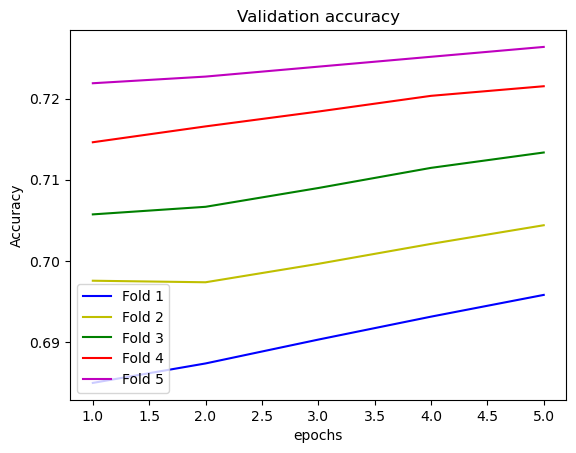

In [592]:
x = np.arange(1,len(val_acc)+1)
plt.plot(x, val_acc[0], 'b', label='Fold 1')
plt.plot(x, val_acc[1], 'y', label='Fold 2')
plt.plot(x, val_acc[2], 'g', label='Fold 3')
plt.plot(x, val_acc[3], 'r', label='Fold 4')
plt.plot(x, val_acc[4], 'm', label='Fold 5')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.title('Validation accuracy')
plt.legend()
plt.show()

#### Fold 1

In [594]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []
sum_loss = 0.0
# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.inference_mode():
        cri = nn.CrossEntropyLoss(weight=weights)
        outputs = model[0](images.to(device))
        loss = cri(outputs, labels.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())
    sum_loss += loss
print(f'Loss = {sum_loss / len(test_loader)}')

Loss = 0.8498789072036743


In [595]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
print(conf_matrix)

# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

[[259  83  15]
 [ 57  89  31]
 [ 37  24 172]]
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       357
           1       0.45      0.50      0.48       177
           2       0.79      0.74      0.76       233

    accuracy                           0.68       767
   macro avg       0.66      0.66      0.66       767
weighted avg       0.69      0.68      0.68       767



<Axes: >

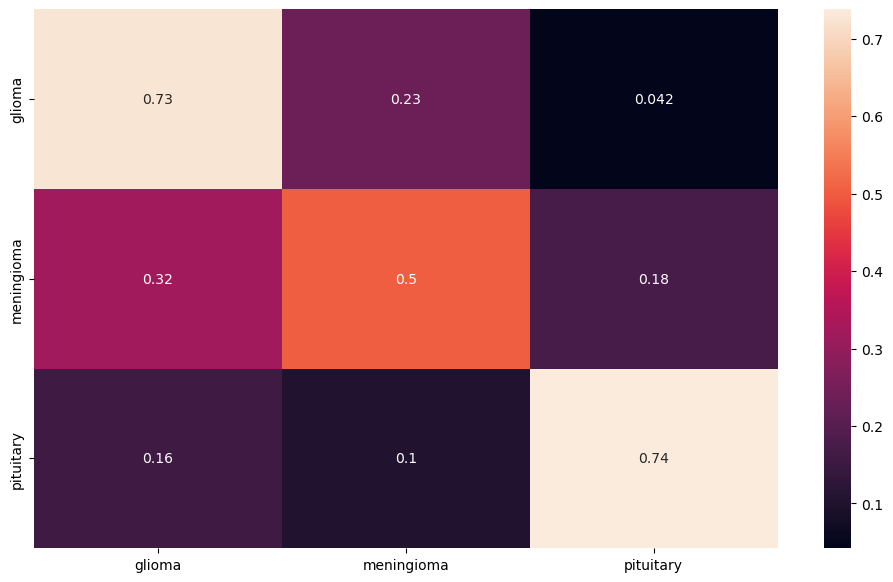

In [596]:
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=1)[:, None],
                     index = ['glioma', 'meningioma', 'pituitary'], columns = ['glioma', 'meningioma', 'pituitary'])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)

#### Fold 2

In [597]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []
sum_loss = 0.0
# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.inference_mode():
        cri = nn.CrossEntropyLoss(weight=weights)
        outputs = model[1](images.to(device))
        loss = cri(outputs, labels.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())
    sum_loss += loss
print(f'Loss = {sum_loss / len(test_loader)}')

Loss = 0.8431642651557922


In [598]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
print(conf_matrix)

# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

[[259  88  10]
 [ 52  96  29]
 [ 30  33 170]]
              precision    recall  f1-score   support

           0       0.76      0.73      0.74       357
           1       0.44      0.54      0.49       177
           2       0.81      0.73      0.77       233

    accuracy                           0.68       767
   macro avg       0.67      0.67      0.67       767
weighted avg       0.70      0.68      0.69       767



<Axes: >

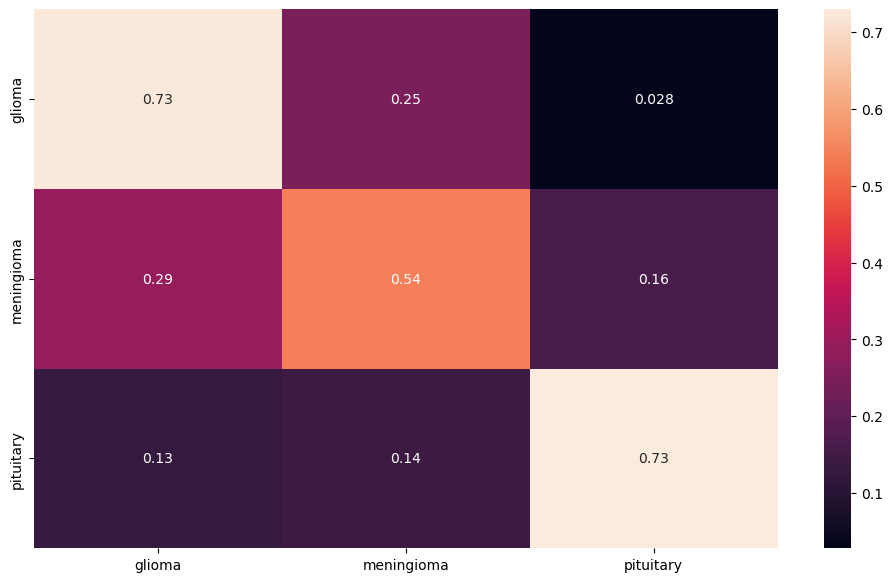

In [599]:
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=1)[:, None],
                     index = ['glioma', 'meningioma', 'pituitary'], columns = ['glioma', 'meningioma', 'pituitary'])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)

#### Fold 3

In [600]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []
sum_loss = 0.0
# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.inference_mode():
        cri = nn.CrossEntropyLoss(weight=weights)
        outputs = model[2](images.to(device))
        loss = cri(outputs, labels.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())
    sum_loss += loss
print(f'Loss = {sum_loss / len(test_loader)}')

Loss = 0.8804245591163635


In [601]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
print(conf_matrix)

# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

[[156 175  26]
 [  8 135  34]
 [  6  39 188]]
              precision    recall  f1-score   support

           0       0.92      0.44      0.59       357
           1       0.39      0.76      0.51       177
           2       0.76      0.81      0.78       233

    accuracy                           0.62       767
   macro avg       0.69      0.67      0.63       767
weighted avg       0.75      0.62      0.63       767



<Axes: >

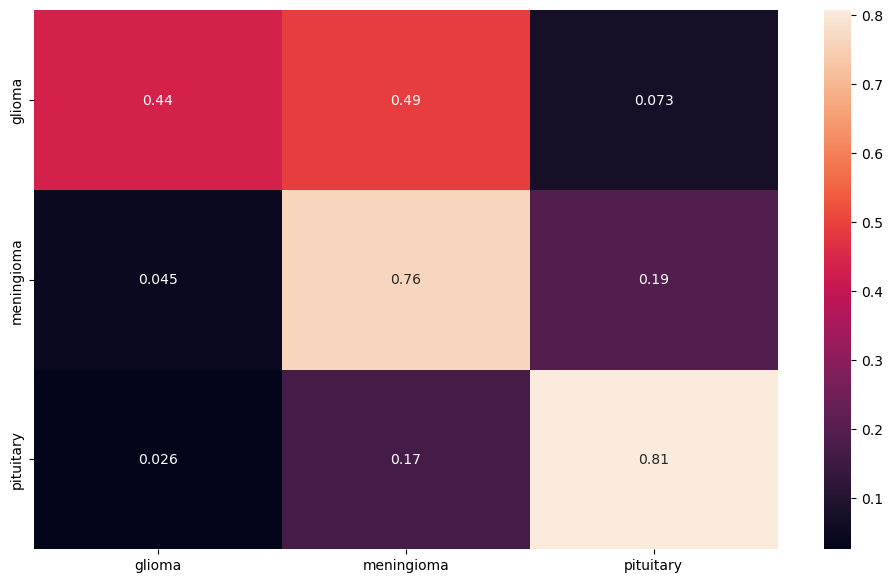

In [602]:
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=1)[:, None],
                     index = ['glioma', 'meningioma', 'pituitary'], columns = ['glioma', 'meningioma', 'pituitary'])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)

#### Fold 4

In [603]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []
sum_loss = 0.0
# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.inference_mode():
        cri = nn.CrossEntropyLoss(weight=weights)
        outputs = model[3](images.to(device))
        loss = cri(outputs, labels.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())
    sum_loss += loss
print(f'Loss = {sum_loss / len(test_loader)}')

Loss = 0.8762403726577759


In [604]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
print(conf_matrix)

# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

[[155 179  23]
 [  1 145  31]
 [  7  40 186]]
              precision    recall  f1-score   support

           0       0.95      0.43      0.60       357
           1       0.40      0.82      0.54       177
           2       0.78      0.80      0.79       233

    accuracy                           0.63       767
   macro avg       0.71      0.68      0.64       767
weighted avg       0.77      0.63      0.64       767



<Axes: >

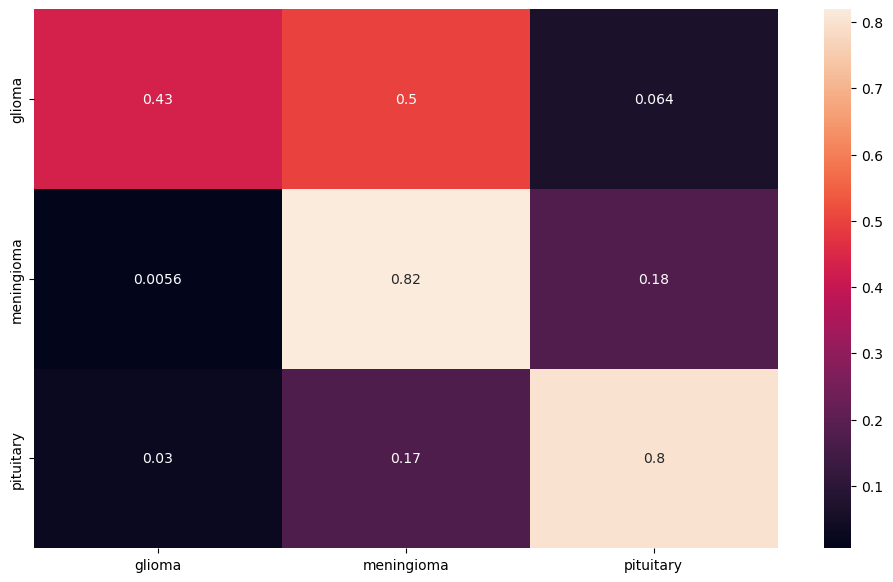

In [605]:
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=1)[:, None],
                     index = ['glioma', 'meningioma', 'pituitary'], columns = ['glioma', 'meningioma', 'pituitary'])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)

#### Fold 5

In [606]:
# Define the lists to store the actual and predicted labels
actual_labels = []
predicted_labels = []
sum_loss = 0.0
# Loop through the dataset and calculate the predicted labels
for images, labels in test_loader:
    with torch.inference_mode():
        cri = nn.CrossEntropyLoss(weight=weights)
        outputs = model[4](images.to(device))
        loss = cri(outputs, labels.to(device))
        predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
        predicted_labels.extend(predictions)
        actual_labels.extend(labels.cpu().numpy())
    sum_loss += loss
print(f'Loss = {sum_loss / len(test_loader)}')

Loss = 0.8609158992767334


In [607]:
# Calculate the confusion matrix
conf_matrix = confusion_matrix(actual_labels, predicted_labels)
print(conf_matrix)

# Calculate the classification report, which includes recall and precision metrics
classification_rep = classification_report(actual_labels, predicted_labels)
print(classification_rep)

[[174 158  25]
 [  6 140  31]
 [  6  34 193]]
              precision    recall  f1-score   support

           0       0.94      0.49      0.64       357
           1       0.42      0.79      0.55       177
           2       0.78      0.83      0.80       233

    accuracy                           0.66       767
   macro avg       0.71      0.70      0.66       767
weighted avg       0.77      0.66      0.67       767



<Axes: >

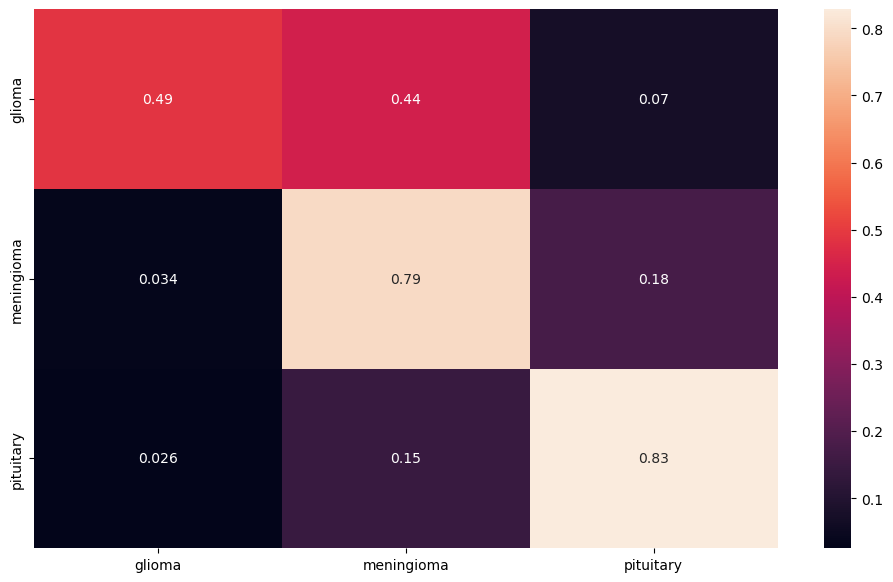

In [608]:
df_cm = pd.DataFrame(conf_matrix / np.sum(conf_matrix, axis=1)[:, None],
                     index = ['glioma', 'meningioma', 'pituitary'], columns = ['glioma', 'meningioma', 'pituitary'])
plt.figure(figsize = (12,7))
sn.heatmap(df_cm, annot=True)

## 50 and 60 and 75 percent of training set

#### 50 percent of dataset

In [29]:
model_50_0 = timm.create_model('inception_resnet_v2', pretrained=True)
model_50_1 = timm.create_model('inception_resnet_v2', pretrained=True)
model_50_2 = timm.create_model('inception_resnet_v2', pretrained=True)
model_50_3 = timm.create_model('inception_resnet_v2', pretrained=True)
model_50_4 = timm.create_model('inception_resnet_v2', pretrained=True)
model_50 = {0 : model_50_0, 1 : model_50_1, 2 : model_50_2, 3 : model_50_3, 4 : model_50_4}

In [35]:
torch.cuda.empty_cache()

kfold = KFold(n_splits=5, shuffle=True, random_state=40)
train_loss = np.zeros((5, 5))
train_acc = np.zeros((5, 5))
val_loss = np.zeros((5, 5))
val_acc = np.zeros((5, 5))
for fold, (train_ids, val_ids) in enumerate(kfold.split(train_dataset_50)):
    torch.cuda.empty_cache()
    # Print
    print(f'FOLD {fold}')
    print('--------------------------------')
    train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
    val_subsampler = torch.utils.data.SubsetRandomSampler(val_ids)
    
    train_loader = torch.utils.data.DataLoader(
    train_dataset_50,
    batch_size=50,
    sampler=train_subsampler,
    num_workers=5,
    )
    
    val_loader = torch.utils.data.DataLoader(
    train_dataset_50,
    batch_size=50,
    sampler=val_subsampler,
    num_workers=5,
    )

    torch.manual_seed(40)
    # freeze all parameters
    for name, para in model_50[fold].named_parameters():
        para.requires_grad = False

    model_50[fold].classif = nn.Sequential(
        nn.Linear(in_features=1536, out_features=2048),
        nn.LeakyReLU(0.2),
        nn.Dropout(p=0.4),
        nn.Linear(in_features=2048, out_features=2048),
        nn.LeakyReLU(0.2),
        nn.Dropout(p=0.4),
        nn.Linear(in_features=2048, out_features=1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(p=0.4),
        nn.Linear(in_features=1024, out_features=3),
        nn.Sigmoid(),
    )

    # turn requires_grad to True for classifier section
    for name, para in model_50[fold].classif.named_parameters():
        para.requires_grad = True

    lr = 0.0001

    # Initialize the model_50[fold] and the optimizer
    model_50[fold] = model_50[fold].to(device)
    optimizer = optim.Adam(model_50[fold].parameters(), lr=lr)


    total_epoch_counter = 0
    # val_loss_counter = 0
    loss_prev = 99999999 #initialized as inf 

    num_epochs = 5
    torch.manual_seed(40)

    for epoch in range(num_epochs):
        # train for one epoch
        loss, train_acc[fold, total_epoch_counter] = train(model_50[fold], train_loader, optimizer, device)
        train_loss[fold, total_epoch_counter] = loss
        print('Train.', end=' ')
        # calculate validation loss for this epoch
        val_loss[fold, total_epoch_counter], val_acc[fold, total_epoch_counter] = validate(model_50[fold], val_loader, device)
        # print the results for this epoch
        print('Epoch [{}/{}], Train loss: {:.4f}, lr: {:.7f}, Validation loss: {:.4f}'
               .format(epoch+1, num_epochs, loss, lr,
                        val_loss[fold, total_epoch_counter]
                      )
             )

        if (loss_prev < loss):
            lr = lr * 0.4
            optimizer = optim.Adam(model_50[fold].parameters(), lr=lr)        
        loss_prev = loss

        total_epoch_counter += 1

FOLD 0
--------------------------------
Train. Epoch [1/5], Train loss: 1.0714, lr: 0.0001000, Validation loss: 1.0005
Train. Epoch [2/5], Train loss: 0.9079, lr: 0.0001000, Validation loss: 0.7939
Train. Epoch [3/5], Train loss: 0.7291, lr: 0.0001000, Validation loss: 0.7006
Train. Epoch [4/5], Train loss: 0.6755, lr: 0.0001000, Validation loss: 0.6771
Train. Epoch [5/5], Train loss: 0.6641, lr: 0.0001000, Validation loss: 0.6966
FOLD 1
--------------------------------
Train. Epoch [1/5], Train loss: 1.0684, lr: 0.0001000, Validation loss: 1.0083
Train. Epoch [2/5], Train loss: 0.9089, lr: 0.0001000, Validation loss: 0.7901
Train. Epoch [3/5], Train loss: 0.7393, lr: 0.0001000, Validation loss: 0.6753
Train. Epoch [4/5], Train loss: 0.6806, lr: 0.0001000, Validation loss: 0.6482
Train. Epoch [5/5], Train loss: 0.6664, lr: 0.0001000, Validation loss: 0.6985
FOLD 2
--------------------------------
Train. Epoch [1/5], Train loss: 1.0717, lr: 0.0001000, Validation loss: 0.9976
Train. Epoc

In [75]:
acc_model_50 = []
precision_model_50 = []
recall_model_50 = []
f1_model_50 = []
loss_model_50 = []
for i in range(5):
    actual_labels = []
    predicted_labels = []
    sum_loss = 0.0
    # Loop through the dataset and calculate the predicted labels
    for images, labels in test_loader:
        with torch.inference_mode():
            cri = nn.CrossEntropyLoss(weight=weights)
            outputs = model_50[i](images.to(device))
            loss = cri(outputs, labels.to(device))
            predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
            predicted_labels.extend(predictions)
            actual_labels.extend(labels.cpu().numpy())
        sum_loss += loss
    print(f'Loss = {sum_loss / len(test_loader)}')
    loss_model_50.append(sum_loss / len(test_loader))
    # Calculate the classification report, which includes recall and precision metrics
    classification_rep = classification_report(actual_labels, predicted_labels)
    precision = float(classification_rep[74:78]) + float(classification_rep[128:132]) + float(classification_rep[182:186])
    precision = precision/3
    precision_model_50.append(precision)
    recall = float(classification_rep[84:88]) + float(classification_rep[138:142]) + float(classification_rep[192:196])
    recall = recall/3
    recall_model_50.append(recall)
    f1 = float(classification_rep[94:98]) + float(classification_rep[148:152]) + float(classification_rep[202:206])
    f1 = f1/3
    f1_model_50.append(f1)
    acc_model_50.append(float(classification_rep[257:261]))

Loss = 0.9747437238693237
Loss = 0.987601637840271
Loss = 0.9825480580329895
Loss = 1.0010778903961182
Loss = 0.9637435674667358


#### 60 percent of dataset

In [77]:
model_60_0 = timm.create_model('inception_resnet_v2', pretrained=True)
model_60_1 = timm.create_model('inception_resnet_v2', pretrained=True)
model_60_2 = timm.create_model('inception_resnet_v2', pretrained=True)
model_60_3 = timm.create_model('inception_resnet_v2', pretrained=True)
model_60_4 = timm.create_model('inception_resnet_v2', pretrained=True)
model_60 = {0 : model_60_0, 1 : model_60_1, 2 : model_60_2, 3 : model_60_3, 4 : model_60_4}

In [78]:
torch.cuda.empty_cache()
kfold = KFold(n_splits=5, shuffle=True, random_state=40)
train_loss = np.zeros((5, 5))
train_acc = np.zeros((5, 5))
val_loss = np.zeros((5, 5))
val_acc = np.zeros((5, 5))
for fold, (train_ids, val_ids) in enumerate(kfold.split(train_dataset_60)):
    
    # Print
    print(f'FOLD {fold}')
    print('--------------------------------')
    train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
    val_subsampler = torch.utils.data.SubsetRandomSampler(val_ids)
    
    train_loader = torch.utils.data.DataLoader(
    train_dataset_60,
    batch_size=50,
    sampler=train_subsampler,
    num_workers=5,
    )
    
    val_loader = torch.utils.data.DataLoader(
    train_dataset_60,
    batch_size=50,
    sampler=val_subsampler,
    num_workers=5,
    )

    torch.manual_seed(40)
    # freeze all parameters
    for name, para in model_60[fold].named_parameters():
        para.requires_grad = False

    model_60[fold].classif = nn.Sequential(
        nn.Linear(in_features=1536, out_features=2048),
        nn.LeakyReLU(0.2),
        nn.Dropout(p=0.4),
        nn.Linear(in_features=2048, out_features=2048),
        nn.LeakyReLU(0.2),
        nn.Dropout(p=0.4),
        nn.Linear(in_features=2048, out_features=1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(p=0.4),
        nn.Linear(in_features=1024, out_features=3),
        nn.Sigmoid(),
    )

    # turn requires_grad to True for classifier section
    for name, para in model_60[fold].classif.named_parameters():
        para.requires_grad = True

    lr = 0.0001

    # Initialize the model_60[fold] and the optimizer
    model_60[fold] = model_60[fold].to(device)
    optimizer = optim.Adam(model_60[fold].parameters(), lr=lr)


    total_epoch_counter = 0
    # val_loss_counter = 0
    loss_prev = 99999999 #initialized as inf 

    num_epochs = 5
    torch.manual_seed(40)

    for epoch in range(num_epochs):
        # train for one epoch
        loss, train_acc[fold, total_epoch_counter] = train(model_60[fold], train_loader, optimizer, device)
        train_loss[fold, total_epoch_counter] = loss
        print('Train.', end=' ')
        # calculate validation loss for this epoch
        val_loss[fold, total_epoch_counter], val_acc[fold, total_epoch_counter] = validate(model_60[fold], val_loader, device)
        # print the results for this epoch
        print('Epoch [{}/{}], Train loss: {:.4f}, lr: {:.7f}, Validation loss: {:.4f}'
               .format(epoch+1, num_epochs, loss, lr,
                        val_loss[fold, total_epoch_counter]
                      )
             )

        if (loss_prev < loss):
            lr = lr * 0.4
            optimizer = optim.Adam(model_60[fold].parameters(), lr=lr)        
        loss_prev = loss

        total_epoch_counter += 1

FOLD 0
--------------------------------
Train. Epoch [1/5], Train loss: 1.0603, lr: 0.0001000, Validation loss: 0.9713
Train. Epoch [2/5], Train loss: 0.8816, lr: 0.0001000, Validation loss: 0.7460
Train. Epoch [3/5], Train loss: 0.7327, lr: 0.0001000, Validation loss: 0.7586
Train. Epoch [4/5], Train loss: 0.6998, lr: 0.0001000, Validation loss: 0.7208
Train. Epoch [5/5], Train loss: 0.6781, lr: 0.0001000, Validation loss: 0.6775
FOLD 1
--------------------------------
Train. Epoch [1/5], Train loss: 1.0581, lr: 0.0001000, Validation loss: 0.9665
Train. Epoch [2/5], Train loss: 0.8666, lr: 0.0001000, Validation loss: 0.7300
Train. Epoch [3/5], Train loss: 0.7364, lr: 0.0001000, Validation loss: 0.7506
Train. Epoch [4/5], Train loss: 0.7053, lr: 0.0001000, Validation loss: 0.6870
Train. Epoch [5/5], Train loss: 0.6730, lr: 0.0001000, Validation loss: 0.6587
FOLD 2
--------------------------------
Train. Epoch [1/5], Train loss: 1.0599, lr: 0.0001000, Validation loss: 0.9778
Train. Epoc

In [79]:
acc_model_60 = []
precision_model_60 = []
recall_model_60 = []
f1_model_60 = []
loss_model_60 = []
for i in range(5):
    actual_labels = []
    predicted_labels = []
    sum_loss = 0.0
    # Loop through the dataset and calculate the predicted labels
    for images, labels in test_loader:
        with torch.inference_mode():
            cri = nn.CrossEntropyLoss(weight=weights)
            outputs = model_60[i](images.to(device))
            loss = cri(outputs, labels.to(device))
            predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
            predicted_labels.extend(predictions)
            actual_labels.extend(labels.cpu().numpy())
        sum_loss += loss
    print(f'Loss = {sum_loss / len(test_loader)}')
    loss_model_60.append(sum_loss / len(test_loader))
    # Calculate the classification report, which includes recall and precision metrics
    classification_rep = classification_report(actual_labels, predicted_labels)
    precision = float(classification_rep[74:78]) + float(classification_rep[128:132]) + float(classification_rep[182:186])
    precision = precision/3
    precision_model_60.append(precision)
    recall = float(classification_rep[84:88]) + float(classification_rep[138:142]) + float(classification_rep[192:196])
    recall = recall/3
    recall_model_60.append(recall)
    f1 = float(classification_rep[94:98]) + float(classification_rep[148:152]) + float(classification_rep[202:206])
    f1 = f1/3
    f1_model_60.append(f1)
    acc_model_60.append(float(classification_rep[257:261]))

Loss = 0.9413283467292786
Loss = 0.9303893446922302
Loss = 0.9382250905036926
Loss = 0.9367643594741821
Loss = 0.9437774419784546


#### 75 percent of dataset

In [80]:
model_75_0 = timm.create_model('inception_resnet_v2', pretrained=True)
model_75_1 = timm.create_model('inception_resnet_v2', pretrained=True)
model_75_2 = timm.create_model('inception_resnet_v2', pretrained=True)
model_75_3 = timm.create_model('inception_resnet_v2', pretrained=True)
model_75_4 = timm.create_model('inception_resnet_v2', pretrained=True)
model_75 = {0 : model_75_0, 1 : model_75_1, 2 : model_75_2, 3 : model_75_3, 4 : model_75_4}

In [81]:
torch.cuda.empty_cache()
kfold = KFold(n_splits=5, shuffle=True, random_state=40)
train_loss = np.zeros((5, 5))
train_acc = np.zeros((5, 5))
val_loss = np.zeros((5, 5))
val_acc = np.zeros((5, 5))
for fold, (train_ids, val_ids) in enumerate(kfold.split(train_dataset_75)):
    torch.cuda.empty_cache()
    # Print
    print(f'FOLD {fold}')
    print('--------------------------------')
    train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
    val_subsampler = torch.utils.data.SubsetRandomSampler(val_ids)
    
    train_loader = torch.utils.data.DataLoader(
    train_dataset_75,
    batch_size=50,
    sampler=train_subsampler,
    num_workers=5,
    )
    
    val_loader = torch.utils.data.DataLoader(
    train_dataset_75,
    batch_size=50,
    sampler=val_subsampler,
    num_workers=5,
    )

    torch.manual_seed(40)
    # freeze all parameters
    for name, para in model_75[fold].named_parameters():
        para.requires_grad = False

    model_75[fold].classif = nn.Sequential(
        nn.Linear(in_features=1536, out_features=2048),
        nn.LeakyReLU(0.2),
        nn.Dropout(p=0.4),
        nn.Linear(in_features=2048, out_features=2048),
        nn.LeakyReLU(0.2),
        nn.Dropout(p=0.4),
        nn.Linear(in_features=2048, out_features=1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(p=0.4),
        nn.Linear(in_features=1024, out_features=3),
        nn.Sigmoid(),
    )

    # turn requires_grad to True for classifier section
    for name, para in model_75[fold].classif.named_parameters():
        para.requires_grad = True

    lr = 0.0001

    # Initialize the model_75[fold] and the optimizer
    model_75[fold] = model_75[fold].to(device)
    optimizer = optim.Adam(model_75[fold].parameters(), lr=lr)


    total_epoch_counter = 0
    # val_loss_counter = 0
    loss_prev = 99999999 #initialized as inf 

    num_epochs = 5
    torch.manual_seed(40)

    for epoch in range(num_epochs):
        # train for one epoch
        loss, train_acc[fold, total_epoch_counter] = train(model_75[fold], train_loader, optimizer, device)
        train_loss[fold, total_epoch_counter] = loss
        print('Train.', end=' ')
        # calculate validation loss for this epoch
        val_loss[fold, total_epoch_counter], val_acc[fold, total_epoch_counter] = validate(model_75[fold], val_loader, device)
        # print the results for this epoch
        print('Epoch [{}/{}], Train loss: {:.4f}, lr: {:.7f}, Validation loss: {:.4f}'
               .format(epoch+1, num_epochs, loss, lr,
                        val_loss[fold, total_epoch_counter]
                      )
             )

        if (loss_prev < loss):
            lr = lr * 0.4
            optimizer = optim.Adam(model_75[fold].parameters(), lr=lr)        
        loss_prev = loss

        total_epoch_counter += 1

FOLD 0
--------------------------------
Train. Epoch [1/5], Train loss: 1.0620, lr: 0.0001000, Validation loss: 0.9588
Train. Epoch [2/5], Train loss: 0.8413, lr: 0.0001000, Validation loss: 0.7357
Train. Epoch [3/5], Train loss: 0.7275, lr: 0.0001000, Validation loss: 0.7010
Train. Epoch [4/5], Train loss: 0.7108, lr: 0.0001000, Validation loss: 0.6936
Train. Epoch [5/5], Train loss: 0.6784, lr: 0.0001000, Validation loss: 0.6872
FOLD 1
--------------------------------
Train. Epoch [1/5], Train loss: 1.0585, lr: 0.0001000, Validation loss: 0.9815
Train. Epoch [2/5], Train loss: 0.8346, lr: 0.0001000, Validation loss: 0.7506
Train. Epoch [3/5], Train loss: 0.7186, lr: 0.0001000, Validation loss: 0.7143
Train. Epoch [4/5], Train loss: 0.7041, lr: 0.0001000, Validation loss: 0.7169
Train. Epoch [5/5], Train loss: 0.6781, lr: 0.0001000, Validation loss: 0.6890
FOLD 2
--------------------------------
Train. Epoch [1/5], Train loss: 1.0595, lr: 0.0001000, Validation loss: 0.9740
Train. Epoc

In [82]:
torch.cuda.empty_cache()
acc_model_75 = []
precision_model_75 = []
recall_model_75 = []
f1_model_75 = []
loss_model_75 = []
for i in range(5):
    actual_labels = []
    predicted_labels = []
    sum_loss = 0.0
    # Loop through the dataset and calculate the predicted labels
    for images, labels in test_loader:
        with torch.inference_mode():
            cri = nn.CrossEntropyLoss(weight=weights)
            outputs = model_75[i](images.to(device))
            loss = cri(outputs, labels.to(device))
            predictions = [torch.argmax(i).cpu().numpy() for i in outputs]
            predicted_labels.extend(predictions)
            actual_labels.extend(labels.cpu().numpy())
        sum_loss += loss
    print(f'Loss = {sum_loss / len(test_loader)}')
    loss_model_75.append(sum_loss / len(test_loader))
    # Calculate the classification report, which includes recall and precision metrics
    classification_rep = classification_report(actual_labels, predicted_labels)
    precision = float(classification_rep[74:78]) + float(classification_rep[128:132]) + float(classification_rep[182:186])
    precision = precision/3
    precision_model_75.append(precision)
    recall = float(classification_rep[84:88]) + float(classification_rep[138:142]) + float(classification_rep[192:196])
    recall = recall/3
    recall_model_75.append(recall)
    f1 = float(classification_rep[94:98]) + float(classification_rep[148:152]) + float(classification_rep[202:206])
    f1 = f1/3
    f1_model_75.append(f1)
    acc_model_75.append(float(classification_rep[257:261]))

Loss = 0.8455177545547485
Loss = 0.8479011654853821
Loss = 0.8534378409385681
Loss = 0.8603162169456482
Loss = 0.8595060110092163


#### plots

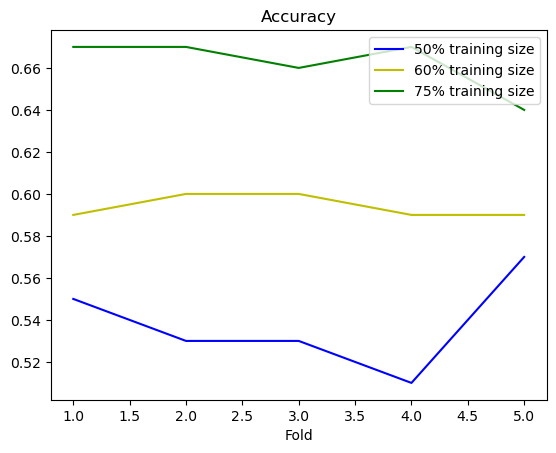

In [83]:
x = np.arange(1,len(acc_model_75)+1)
plt.plot(x, acc_model_50, 'b', label='50% training size')
plt.plot(x, acc_model_60, 'y', label='60% training size')
plt.plot(x, acc_model_75, 'g', label='75% training size')
plt.xlabel('Fold')
plt.title('Accuracy')
plt.legend()
plt.show()

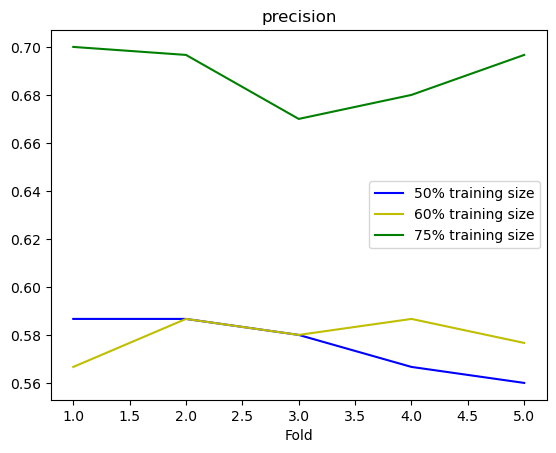

In [85]:
x = np.arange(1,len(precision_model_75)+1)
plt.plot(x, precision_model_50, 'b', label='50% training size')
plt.plot(x, precision_model_60, 'y', label='60% training size')
plt.plot(x, precision_model_75, 'g', label='75% training size')
plt.xlabel('Fold')
plt.title('precision')
plt.legend()
plt.show()

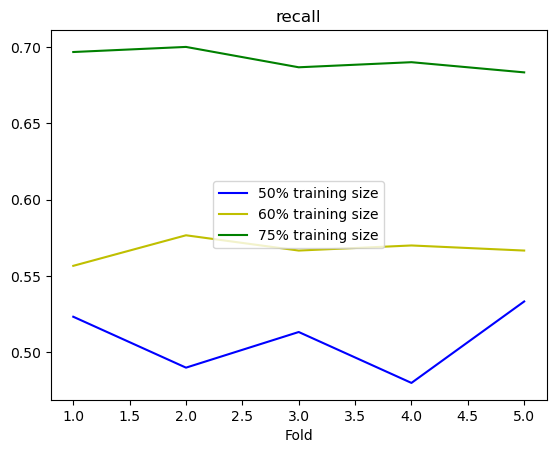

In [86]:
x = np.arange(1,len(recall_model_75)+1)
plt.plot(x, recall_model_50, 'b', label='50% training size')
plt.plot(x, recall_model_60, 'y', label='60% training size')
plt.plot(x, recall_model_75, 'g', label='75% training size')
plt.xlabel('Fold')
plt.title('recall')
plt.legend()
plt.show()

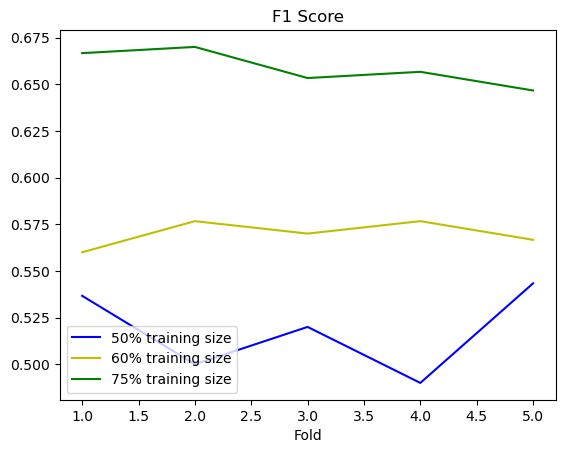

In [87]:
x = np.arange(1,len(f1_model_75)+1)
plt.plot(x, f1_model_50, 'b', label='50% training size')
plt.plot(x, f1_model_60, 'y', label='60% training size')
plt.plot(x, f1_model_75, 'g', label='75% training size')
plt.xlabel('Fold')
plt.title('F1 Score')
plt.legend()
plt.show()

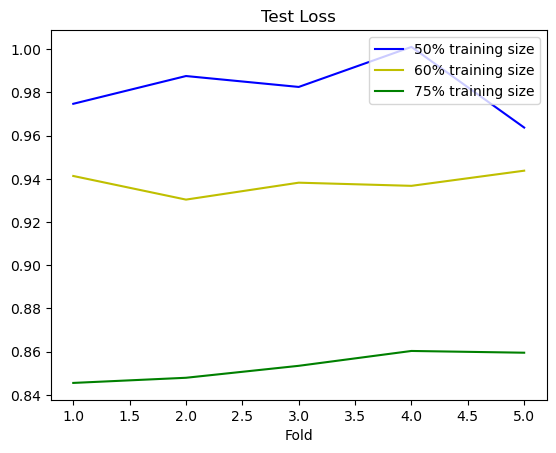

In [93]:
loss_model_50_c = [i.cpu() for i in loss_model_50]
loss_model_60_c = [i.cpu() for i in loss_model_60]
loss_model_75_c = [i.cpu() for i in loss_model_75]
x = np.arange(1,len(loss_model_75_c)+1)
plt.plot(x, loss_model_50_c, 'b', label='50% training size')
plt.plot(x, loss_model_60_c, 'y', label='60% training size')
plt.plot(x, loss_model_75_c, 'g', label='75% training size')
plt.xlabel('Fold')
plt.title('Test Loss')
plt.legend()
plt.show()